# Load Data

In [1]:
import json 
with open('/kaggle/input/brain-tumor-image-dataset-semantic-segmentation/valid/_annotations.coco.json','r') as file:
    data = json.load(file)

for img in data['images'][:10]:
    print(img['file_name'])

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/brain-tumor-image-dataset-semantic-segmentation/valid/_annotations.coco.json'

In [2]:
import json
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import os

# EDA

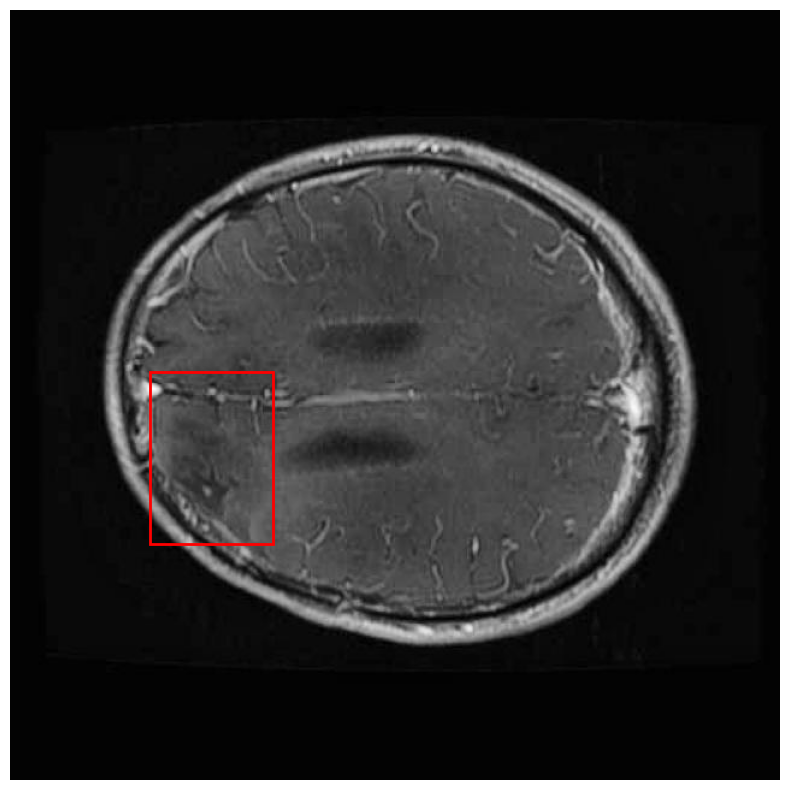

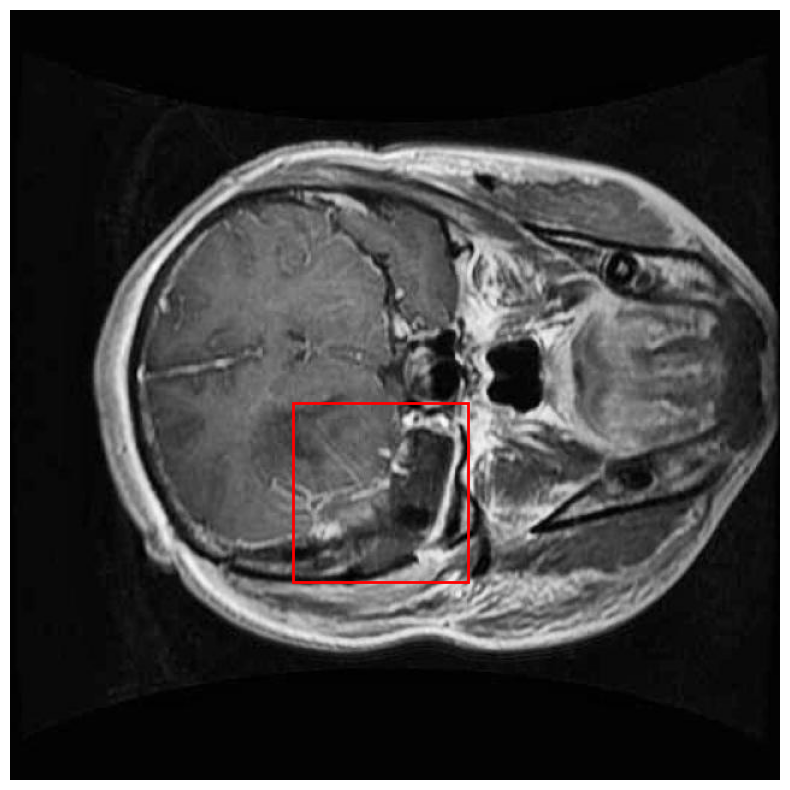

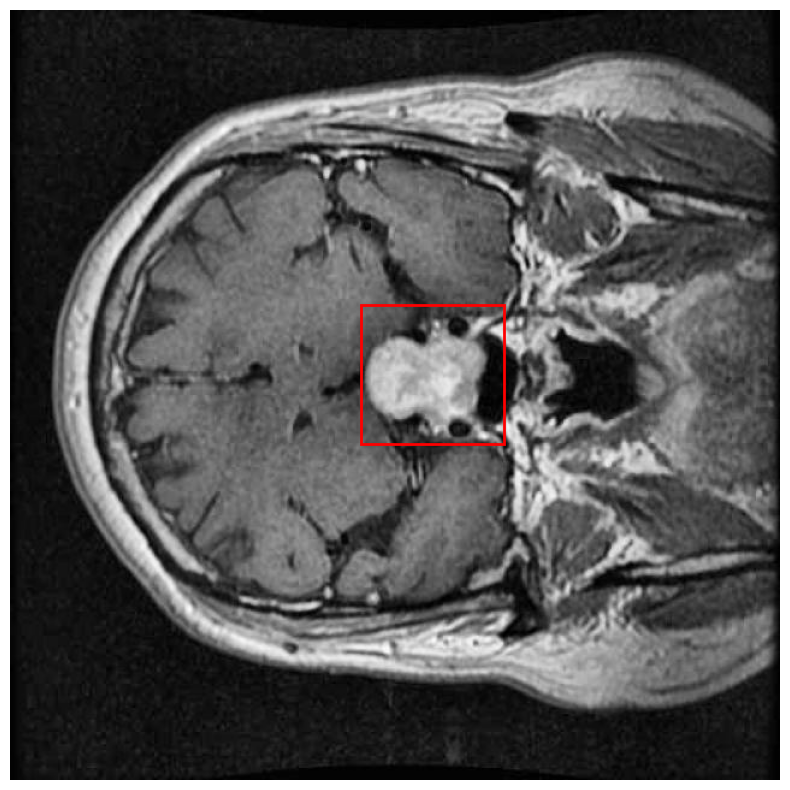

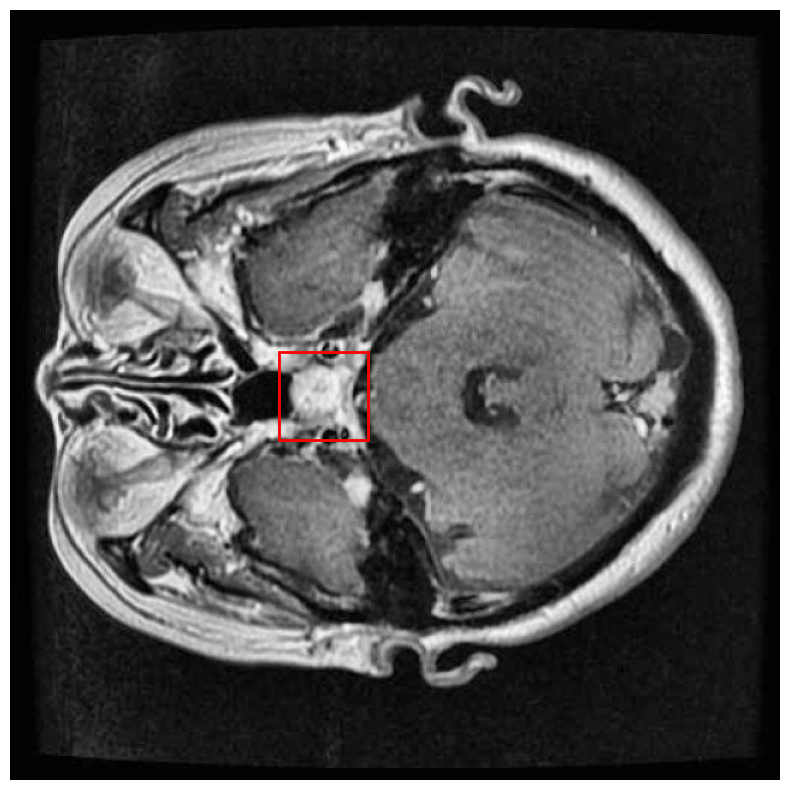

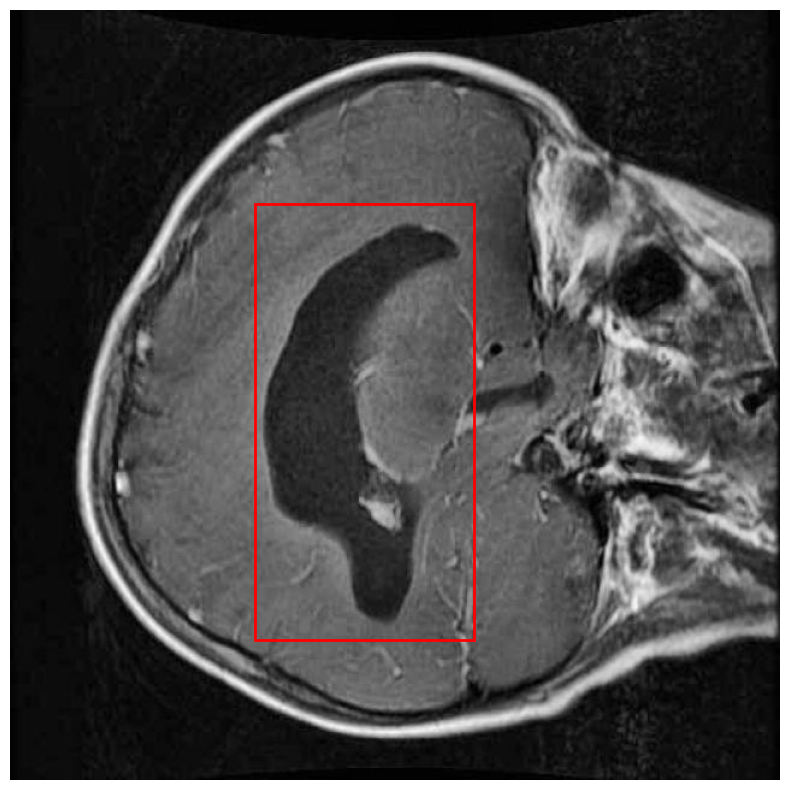

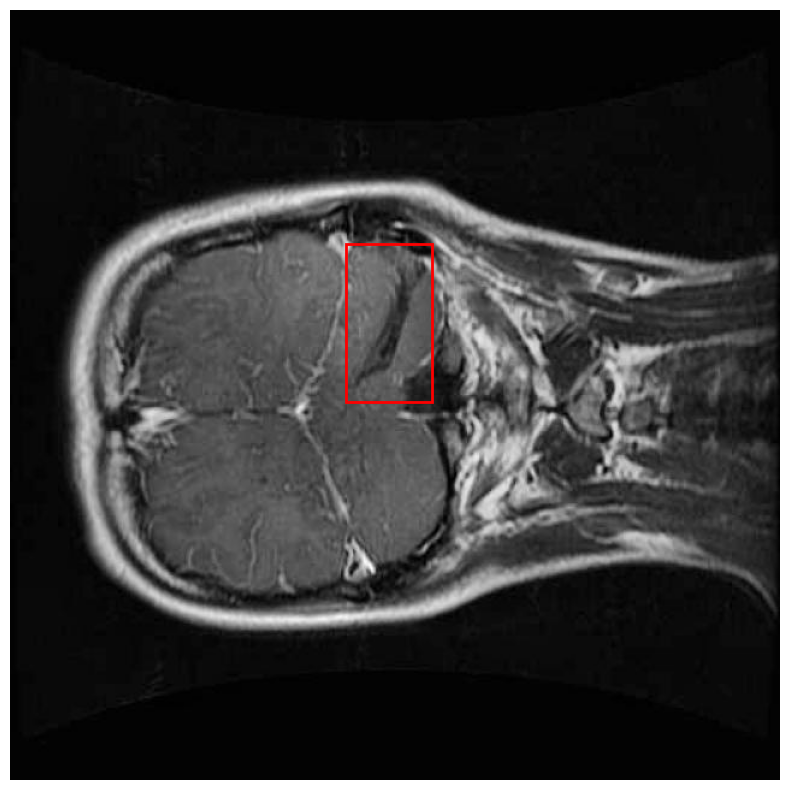

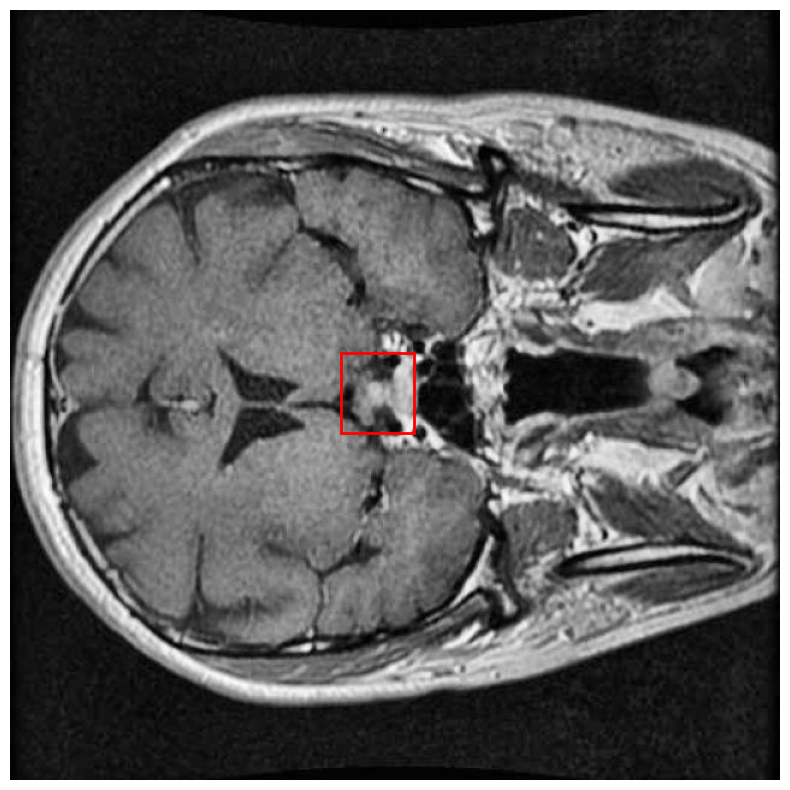

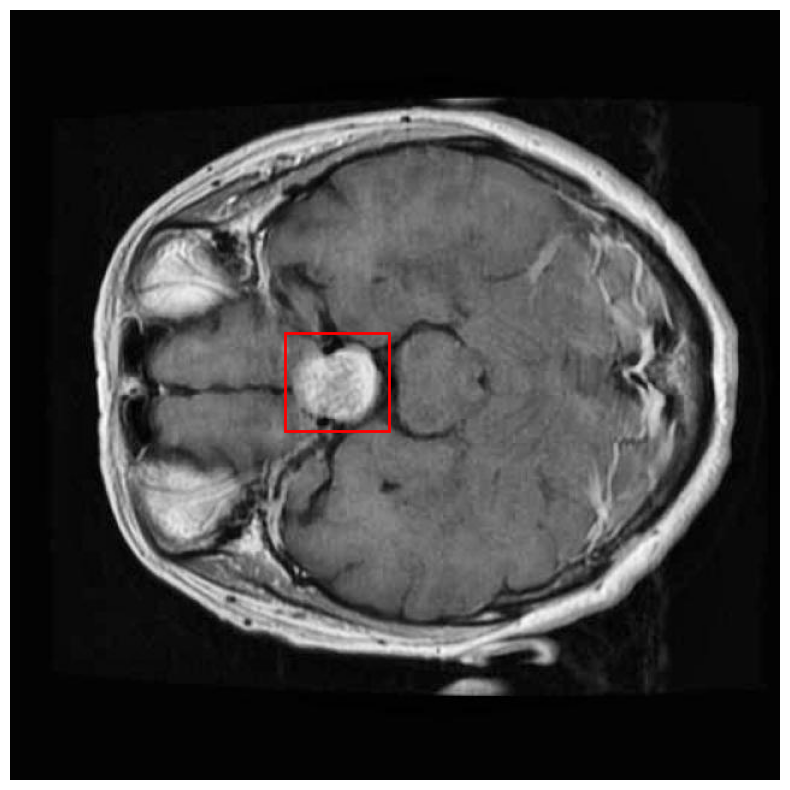

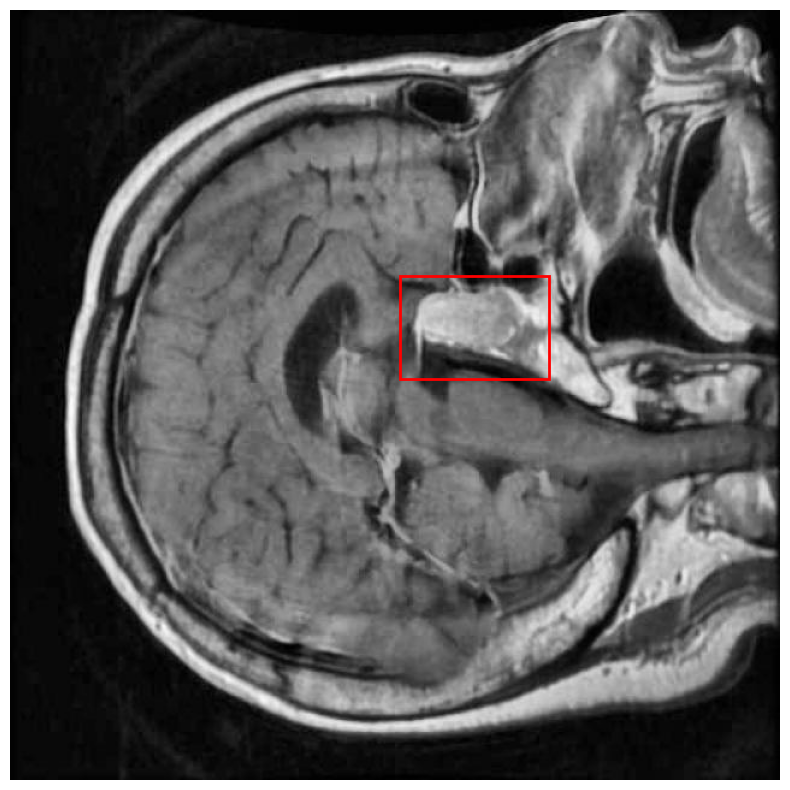

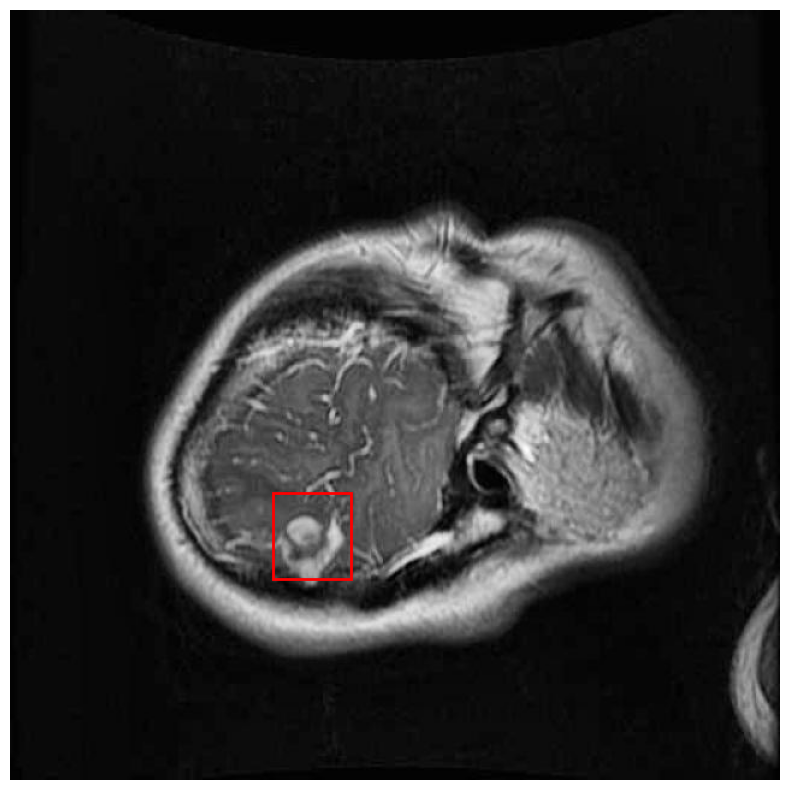

In [3]:
image_dir = '/kaggle/input/brain-tumor-image-dataset-semantic-segmentation/valid'

def display_image_with_annotations(img_data, annotations, image_dir):
    file_name = img_data['file_name']
    img_path = os.path.join(image_dir, file_name)
    
    image = Image.open(img_path)
    plt.figure(figsize=(10, 10))
    plt.imshow(image)
    
    img_id = img_data['id']
    img_annotations = [ann for ann in annotations if ann['image_id'] == img_id]
    
    ax = plt.gca()
    
    for ann in img_annotations:
        bbox = ann['bbox']
        rect = patches.Rectangle((bbox[0], bbox[1]), bbox[2], bbox[3], linewidth=2, edgecolor='r', facecolor='none')
        ax.add_patch(rect)
    
    plt.axis('off')
    plt.show()


for img in data['images'][:10]:
    display_image_with_annotations(img, data['annotations'], image_dir)

## Change JSON to MASK

In [4]:
import numpy as np
import skimage.draw
import tifffile
import shutil

def create_mask(image_info, annotations, output_folder, max_print=3):

    mask_np = np.zeros((image_info['height'], image_info['width']), dtype=np.uint8)
    object_number = 1
    printed_masks = 0  # Count the number of printed masks
    for ann in annotations:
        if ann['image_id'] == image_info['id']:
            for seg_idx, seg in enumerate(ann['segmentation']):
                rr, cc = skimage.draw.polygon(seg[1::2], seg[0::2], mask_np.shape)
                
                seg_mask = np.zeros_like(mask_np, dtype=np.uint8)
                seg_mask[rr, cc] = 255 
                mask_path = os.path.join(output_folder, f"{image_info['file_name'].replace('.jpg', '')}_seg_{seg_idx}.tif")
                tifffile.imwrite(mask_path, seg_mask)
                printed_masks += 1
                if printed_masks >= max_print:
                    return 

In [5]:
def main(json_file, mask_output_folder, image_output_folder, original_image_dir):
    # Load COCO JSON annotations
    with open(json_file, 'r') as f:
        data = json.load(f)

    images = data['images']
    annotations = data['annotations']

    # Ensure the output directories exist
    if not os.path.exists(mask_output_folder):
        os.makedirs(mask_output_folder)
    if not os.path.exists(image_output_folder):
        os.makedirs(image_output_folder)

    for img in images:
        create_mask(img, annotations, mask_output_folder)

        original_image_path = os.path.join(original_image_dir, img['file_name'])
        new_image_path = os.path.join(image_output_folder, os.path.basename(original_image_path))
        shutil.copy2(original_image_path, new_image_path)

In [6]:
original_image_dir = '/kaggle/input/brain-tumor-image-dataset-semantic-segmentation/test'  
json_file = '/kaggle/input/brain-tumor-image-dataset-semantic-segmentation/test/_annotations.coco.json'
mask_output_folder = 'test2/masks' 
image_output_folder = 'test2/images' 
main(json_file, mask_output_folder, image_output_folder, original_image_dir)

original_image_dir = '/kaggle/input/brain-tumor-image-dataset-semantic-segmentation/train' 
json_file = '/kaggle/input/brain-tumor-image-dataset-semantic-segmentation/train/_annotations.coco.json'
mask_output_folder = 'train2/masks/' 
image_output_folder = 'train2/images' 
main(json_file, mask_output_folder, image_output_folder, original_image_dir)

original_image_dir = '/kaggle/input/brain-tumor-image-dataset-semantic-segmentation/valid' 
json_file = '/kaggle/input/brain-tumor-image-dataset-semantic-segmentation/valid/_annotations.coco.json'
mask_output_folder = 'valid2/masks'  
image_output_folder = 'valid2/images'  
main(json_file, mask_output_folder, image_output_folder, original_image_dir)

In [7]:
def compare_folders_and_delete(folder1_path, folder2_path):
    folder1_items = os.listdir(folder1_path)
    folder2_items = os.listdir(folder2_path)

    for item1 in folder1_items:
        found = False
        for item2 in folder2_items:
            if item1[:4] == item2[:4]:
                found = True
                break
        if not found:
            print(f"Corresponding item for {item1} not found.")
            item1_path = os.path.join(folder1_path, item1)
            os.remove(item1_path)
            print(f"Deleted {item1}")

    for item2 in folder2_items:
        found = False
        for item1 in folder1_items:
            if item2[:4] == item1[:4]:
                found = True
                break
        if not found:
            print(f"Corresponding item for {item2} not found.")
            item2_path = os.path.join(folder2_path, item2)
            os.remove(item2_path)
            print(f"Deleted {item2}")

# Example usage:
folder1_path = "/kaggle/working/valid2/images"
folder2_path = "/kaggle/working/valid2/masks"
compare_folders_and_delete(folder1_path, folder2_path)

# GLOBAL VARIABLE

In [1]:
BATCH_SIZE = 32
NUM_EPOCHS = 35
LEARNING_RATE =1e-3

# Create Custom Dataset for PyTorch

In [2]:
import os
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image

class CustomDataset_general(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.image_folder = os.path.join(root_dir, "images")
        self.mask_folder = os.path.join(root_dir, "masks")
        self.image_files = sorted(os.listdir(self.image_folder))
        self.mask_files = sorted(os.listdir(self.mask_folder))
        self.transform = transform

    def __len__(self):
        return len(self.mask_files)

    def __getitem__(self, idx):
        # Read image
        img_name = self.image_files[idx]
        img_path = os.path.join(self.image_folder, img_name)
        image = Image.open(img_path).convert("RGB")
        image_gray = image.convert("L")  # Convert to grayscale

        # Read corresponding mask
        mask_name = self.mask_files[idx]
        mask_path = os.path.join(self.mask_folder, mask_name)
        mask = Image.open(mask_path).convert("L")

        if self.transform:
            # Apply transformations
            image_gray = self.transform(image_gray)
            mask = self.transform(mask)

        return image_gray, mask

train_path = "train2" 
valid_path = "valid2"
test_path = "test2"

image_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485], std=[0.229]),  # Assuming grayscale images
    transforms.Lambda(lambda x: x.clamp(0, 1))
])

# Create datasets
train_dataset = CustomDataset_general(train_path, transform=image_transform)
valid_dataset = CustomDataset_general(valid_path, transform=image_transform)
test_dataset = CustomDataset_general(test_path, transform=image_transform)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [3]:
print(len(train_loader))

47


In [4]:
if len(train_loader) > 0:
    x, y = next(iter(train_loader))
    print(x.shape , y.shape , type(x) , type(y))
else:
    print("Train loader is empty.")

torch.Size([32, 1, 224, 224]) torch.Size([32, 1, 224, 224]) <class 'torch.Tensor'> <class 'torch.Tensor'>


# Modelling

## Import Libraries

In [5]:
import torch
from torchvision import datasets
from torchmetrics.classification import JaccardIndex
from torch.utils.data import Dataset ,DataLoader
from torchvision.transforms import ToTensor
import torch.nn as nn
import pandas as pd
import numpy as np
from torch.optim import lr_scheduler

## Loss

In [6]:
import torch.nn.functional as F

class DiceLoss(nn.Module):
    def __init__(self):
        super(DiceLoss, self).__init__()
        
    def forward(self, y_pred, y_true):
        y_pred = torch.sigmoid(y_pred)
        smooth = 1.0
        y_pred = y_pred.reshape(-1)
        y_true = y_true.reshape(-1)
        intersection = (y_pred * y_true).sum()
        
        dic_loss = 1 - (2.0 * intersection + smooth) / (y_pred.sum() + y_true.sum() + smooth)
        return dic_loss

## Import Backbone

In [8]:
%pip install -U git+https://github.com/jlcsilva/segmentation_models.pytorch

  Cloning https://github.com/jlcsilva/segmentation_models.pytorch to /tmp/pip-req-build-wxydog7r
  Running command git clone --filter=blob:none --quiet https://github.com/jlcsilva/segmentation_models.pytorch /tmp/pip-req-build-wxydog7r
  Resolved https://github.com/jlcsilva/segmentation_models.pytorch to commit 44a5593bfb1c8f2a3f5f23303c02e6f7e2f11170
  Preparing metadata (setup.py) ... done
Note: you may need to restart the kernel to use updated packages.


In [ ]:
%pip install torchsummary

Note: you may need to restart the kernel to use updated packages.


### Model 1: UnFreeze All Layers

In [12]:
import segmentation_models_pytorch as smp
import torch.nn as nn
import torchsummary

class ModifiedUnet(smp.Unet):
    def __init__(self, encoder_name, encoder_weights, in_channels, classes, activation):
        super(ModifiedUnet, self).__init__(
            encoder_name=encoder_name,
            encoder_weights=encoder_weights,
            in_channels=in_channels,
            classes=classes,
            activation=activation
        )
        
        self.encoder = self.add_batchnorm(self.encoder)
        
        self.decoder = self.add_dropout(self.decoder)
        
        self.classification_head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(self.encoder.out_channels[-1], 64), 
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 1)
        )

    def add_batchnorm(self, module):
        for name, layer in module.named_children():
            if isinstance(layer, nn.Conv2d):
                module.add_module(name, nn.Sequential(layer, nn.BatchNorm2d(layer.out_channels)))
            elif isinstance(layer, nn.Sequential) or isinstance(layer, nn.ModuleList):
                self.add_batchnorm(layer)
        return module

    def add_dropout(self, module):
        for name, layer in module.named_children():
            if isinstance(layer, nn.Conv2d):
                module.add_module(name, nn.Sequential(layer, nn.Dropout(0.5)))  
            elif isinstance(layer, nn.Sequential) or isinstance(layer, nn.ModuleList):
                self.add_dropout(layer)
        return module

    def forward(self, x):
        features = self.encoder(x)
        decoder_output = self.decoder(*features)
        masks = self.segmentation_head(decoder_output)
        
        # Applying classification head
        classification_output = self.classification_head(features[-1])
        
        return masks, classification_output

# Define constants
ENCODER = 'efficientnet-b0'
ENCODER_WEIGHTS = 'imagenet'
DEVICE = 'cuda'
ACTIVATION = None

model1 = ModifiedUnet(
    encoder_name=ENCODER, 
    encoder_weights=ENCODER_WEIGHTS, 
    in_channels=1, 
    classes=1, 
    activation=ACTIVATION,
)

model1.to(DEVICE)
print(torchsummary.summary(model1, (1, 224, 224)))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
         ZeroPad2d-1          [-1, 1, 225, 225]               0
Conv2dStaticSamePadding-2         [-1, 32, 112, 112]             288
       BatchNorm2d-3         [-1, 32, 112, 112]              64
       BatchNorm2d-4         [-1, 32, 112, 112]              64
MemoryEfficientSwish-5         [-1, 32, 112, 112]               0
         ZeroPad2d-6         [-1, 32, 114, 114]               0
Conv2dStaticSamePadding-7         [-1, 32, 112, 112]             288
       BatchNorm2d-8         [-1, 32, 112, 112]              64
MemoryEfficientSwish-9         [-1, 32, 112, 112]               0
         Identity-10             [-1, 32, 1, 1]               0
Conv2dStaticSamePadding-11              [-1, 8, 1, 1]             264
MemoryEfficientSwish-12              [-1, 8, 1, 1]               0
         Identity-13              [-1, 8, 1, 1]               0
Conv2dStaticSame

### Model 2: Freeze all encoder layers

In [13]:
import segmentation_models_pytorch as smp
import torch.nn as nn
import torchsummary

class ModifiedUnet(smp.Unet):
    def __init__(self, encoder_name, encoder_weights, in_channels, classes, activation):
        super(ModifiedUnet, self).__init__(
            encoder_name=encoder_name,
            encoder_weights=encoder_weights,
            in_channels=in_channels,
            classes=classes,
            activation=activation
        )
        
        self.encoder = self.add_batchnorm(self.encoder)
        
        self.decoder = self.add_dropout(self.decoder)
        
        self.classification_head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(self.encoder.out_channels[-1], 64),
            nn.ReLU(),
            nn.Dropout(0.5), 
            nn.Linear(64, 1) 
        )

    def add_batchnorm(self, module):
        for name, layer in module.named_children():
            if isinstance(layer, nn.Conv2d):
                module.add_module(name, nn.Sequential(layer, nn.BatchNorm2d(layer.out_channels)))
            elif isinstance(layer, nn.Sequential) or isinstance(layer, nn.ModuleList):
                self.add_batchnorm(layer)
        return module

    def add_dropout(self, module):
        for name, layer in module.named_children():
            if isinstance(layer, nn.Conv2d):
                module.add_module(name, nn.Sequential(layer, nn.Dropout(0.5))) 
            elif isinstance(layer, nn.Sequential) or isinstance(layer, nn.ModuleList):
                self.add_dropout(layer)
        return module

    def freeze_encoder(self):
        for param in self.encoder.parameters():
            param.requires_grad = False

    def forward(self, x):
        features = self.encoder(x)
        decoder_output = self.decoder(*features)
        masks = self.segmentation_head(decoder_output)
        
        classification_output = self.classification_head(features[-1])
        
        return masks, classification_output

ENCODER = 'efficientnet-b0'
ENCODER_WEIGHTS = 'imagenet'
DEVICE = 'cuda'
ACTIVATION = None

model2 = ModifiedUnet(
    encoder_name=ENCODER, 
    encoder_weights=ENCODER_WEIGHTS, 
    in_channels=1, 
    classes=1, 
    activation=ACTIVATION,
)

model2.freeze_encoder()

model2.to(DEVICE)
print(torchsummary.summary(model2, (1, 224, 224)))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
         ZeroPad2d-1          [-1, 1, 225, 225]               0
Conv2dStaticSamePadding-2         [-1, 32, 112, 112]             288
       BatchNorm2d-3         [-1, 32, 112, 112]              64
       BatchNorm2d-4         [-1, 32, 112, 112]              64
MemoryEfficientSwish-5         [-1, 32, 112, 112]               0
         ZeroPad2d-6         [-1, 32, 114, 114]               0
Conv2dStaticSamePadding-7         [-1, 32, 112, 112]             288
       BatchNorm2d-8         [-1, 32, 112, 112]              64
MemoryEfficientSwish-9         [-1, 32, 112, 112]               0
         Identity-10             [-1, 32, 1, 1]               0
Conv2dStaticSamePadding-11              [-1, 8, 1, 1]             264
MemoryEfficientSwish-12              [-1, 8, 1, 1]               0
         Identity-13              [-1, 8, 1, 1]               0
Conv2dStaticSame

### Model 3 : Efficient Unet++ from [segmentation_models_pytorch]

In [10]:
import segmentation_models_pytorch as smp
import torch.nn as nn
import torchsummary


# Define constants
ENCODER = 'efficientnet-b0'
ENCODER_WEIGHTS = 'imagenet'
DEVICE = 'cuda'
ACTIVATION = None

model3 = smp.EfficientUnetPlusPlus(
    in_channels=1, 
    classes=1, 
)

model3.to(DEVICE)
print(torchsummary.summary(model3, (1, 224, 224)))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 48, 112, 112]             432
       BatchNorm2d-2         [-1, 48, 112, 112]              96
             Swish-3         [-1, 48, 112, 112]               0
            Conv2d-4         [-1, 48, 112, 112]             432
       BatchNorm2d-5         [-1, 48, 112, 112]              96
             Swish-6         [-1, 48, 112, 112]               0
            Conv2d-7             [-1, 12, 1, 1]             588
             Swish-8             [-1, 12, 1, 1]               0
            Conv2d-9             [-1, 48, 1, 1]             624
          Sigmoid-10             [-1, 48, 1, 1]               0
    SqueezeExcite-11         [-1, 48, 112, 112]               0
           Conv2d-12         [-1, 24, 112, 112]           1,152
      BatchNorm2d-13         [-1, 24, 112, 112]              48
         Identity-14         [-1, 24, 1

## Hyperparameters

In [14]:
checkpoints_path = "exp/checkpoints.pth"
os.makedirs("exp", exist_ok=True)

optimizer1 = torch.optim.Adam(model1.parameters(), lr=LEARNING_RATE)
optimizer2 = torch.optim.Adam(model2.parameters(), lr=LEARNING_RATE)
optimizer3 = torch.optim.Adam(model3.parameters(), lr=LEARNING_RATE)

loss_fn = DiceLoss()

In [15]:
def compute_iou(outputs, targets):
    intersection = torch.logical_and(outputs, targets).sum()
    union = torch.logical_or(outputs, targets).sum()
    iou = intersection.float() / union.float()
    return iou.item()

## Define Train and Validation Functions

In [16]:
def train(model, optimizer, loss_fn, loader, device):
    epoch_loss = 0.0
    epoch_iou = 0.0
    model.train()

    for x, y in tqdm(loader):
        x = x.to(device, dtype=torch.float32)
        y = y.to(device, dtype=torch.float32)
        optimizer.zero_grad()
        
        masks, _ = model(x)  # Split the output of the model
        loss = loss_fn(masks, y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        
        # Compute IoU
        preds = (masks > 0.5).float()  # Convert probabilities to binary predictions
        iou = compute_iou(preds, y)
        epoch_iou += iou

    return epoch_loss / len(loader), epoch_iou / len(loader)


In [17]:
def valid(model, loader, loss_fn, device):
    epoch_loss = 0.0
    epoch_iou = 0.0
    model.eval()

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device, dtype=torch.float32)
            y = y.to(device, dtype=torch.float32)
            
            masks, _ = model(x) 
            loss = loss_fn(masks, y)
            epoch_loss += loss.item()
            
            # Compute IoU
            preds = (masks > 0.5).float()  
            iou = compute_iou(preds, y)
            epoch_iou += iou

    return epoch_loss / len(loader), epoch_iou / len(loader)


## Model Training

### Model 1

In [21]:
from tqdm import tqdm
from IPython.display import clear_output

best_val_loss = float('inf')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_losses = []
val_losses = []
train_ious = []
val_ious = []
num_no_improve = 0

model1.to(device)  

for epoch in range(NUM_EPOCHS):
    train_loss, train_iou = train(model1, optimizer1, loss_fn, train_loader, device) 
    val_loss, val_iou = valid(model1, valid_loader, loss_fn, device) 
    
    train_losses.append(train_loss) 
    val_losses.append(val_loss)  
    train_ious.append(train_iou)  
    val_ious.append(val_iou)  
    
    clear_output(wait=True)
    print(f'Epoch {epoch+1}/{NUM_EPOCHS}, Train Loss: {train_loss:.4f}, Train IoU: {train_iou:.4f}')
    print(f'Validation Loss: {val_loss:.4f}, Validation IoU: {val_iou:.4f}')
    
    if val_loss < best_val_loss:  
        best_val_loss = val_loss
        print("Saving the model")
        torch.save(model1.state_dict(), checkpoints_path) 
    
    if val_loss > best_val_loss:
        best_dict = torch.load(checkpoints_path)
        print('Loading Best Model')
        model1.load_state_dict(best_dict)
    
    if len(val_losses) > 1: 
        if val_loss <= best_val_loss: 
            num_no_improve += 1
        else:
            num_no_improve = 0
            
    if num_no_improve >= 10:
        print("Early stopping")
        break


Epoch 35/35, Train Loss: 0.2004, Train IoU: 0.6696
Validation Loss: 0.3147, Validation IoU: 0.5377
Loading Best Model


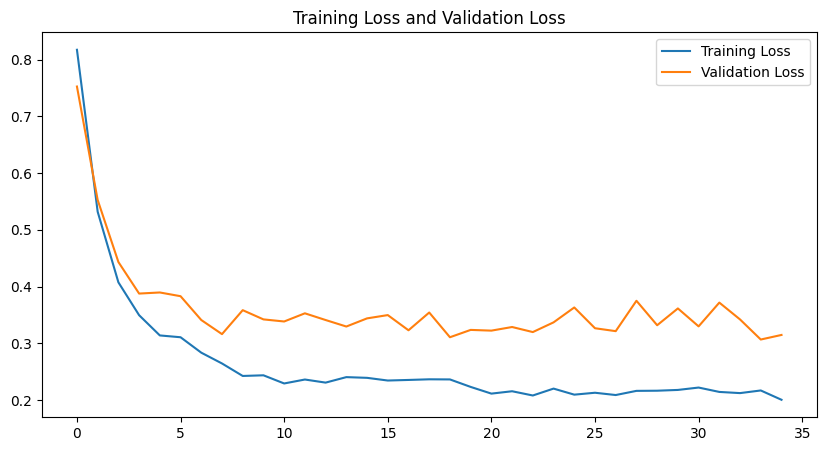

In [22]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training Loss and Validation Loss')
plt.legend()
plt.show(block=False)

The Dice loss of 0.2004 and Train IoU of 0.6696 on the train data indicated that more of the true image and predicted image on the train data is correctly classified, this shows us that the model is performing good on the train data. The model can be improved by increasing the number of epochs, increasing the learning rate, and increasing the batch size.

The Diceloss of the validation data is 0.3147, with it having more than half the diceloss of the train data this shows that the model is a little overfitting. The model can be improved by increasing the number of epochs, increasing the learning rate, and increasing the batch size.

The overfitting of the model can also be seen on the graph wtih the validation and training loss having such a large gap, with training lossbeing in the bottom

The form of the predicted mask is also rectangular, which could be more suited to image detection tasks. The prediction maybe improved by using a different model approach.

#### Model Inferencing

In [23]:
test_loss = valid(model1,test_loader,loss_fn,device)
print(f'Test data DiceLoss, IOU : {test_loss}')

Test data DiceLoss, IOU : (0.32375526428222656, 0.5242226421833038)


With the Test data diceloss of 0.4335, it meant that around 43% of the predicted point is not overlapping with the ground truth. Or in layman terms, the model has an average error rate of 43%

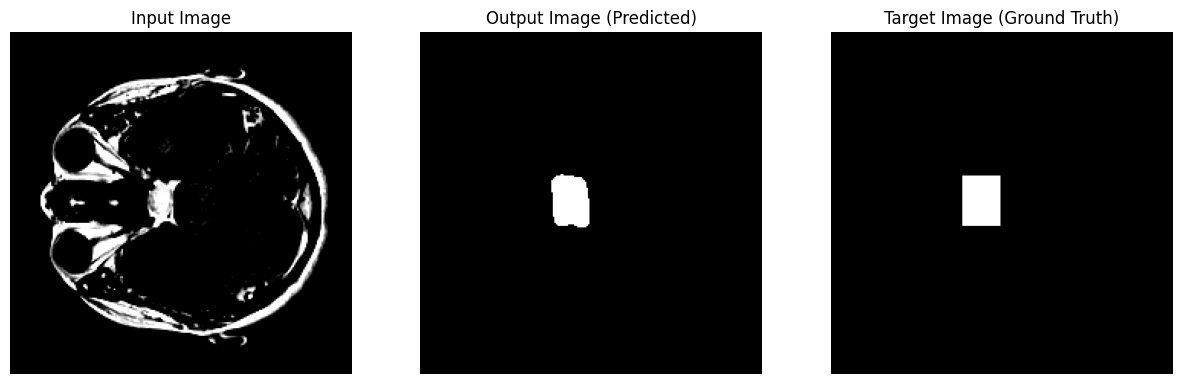

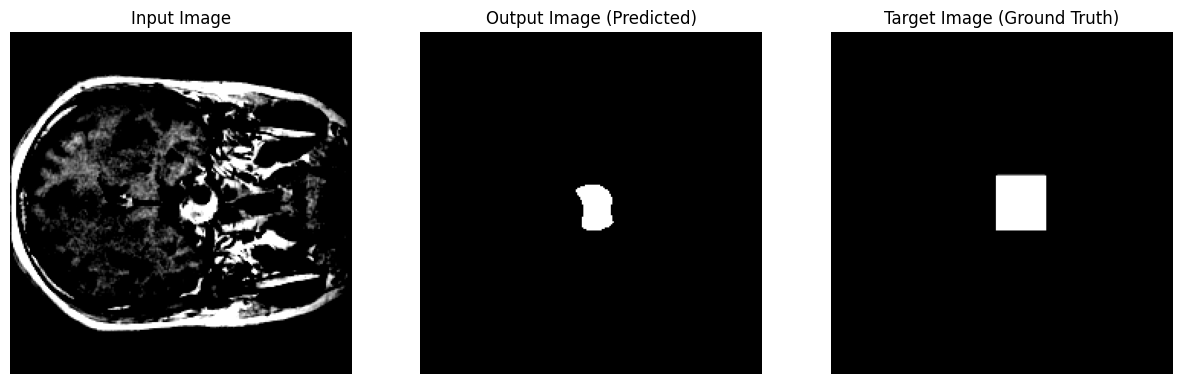

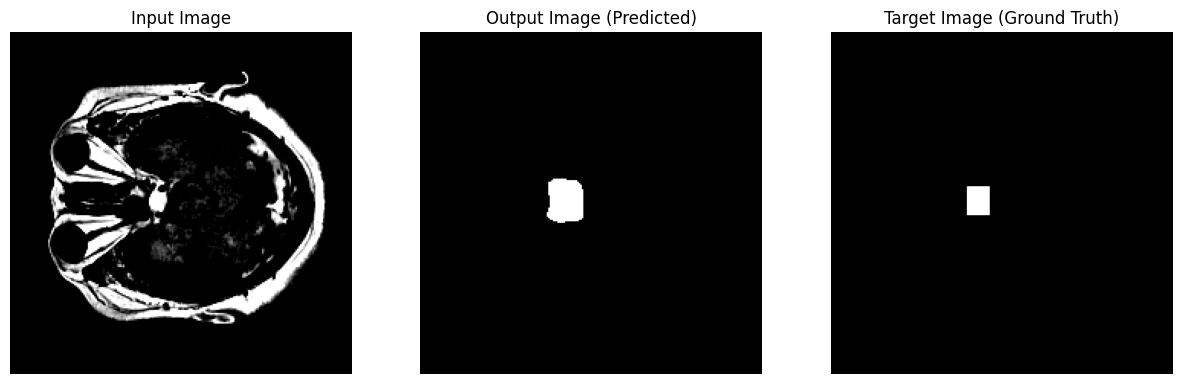

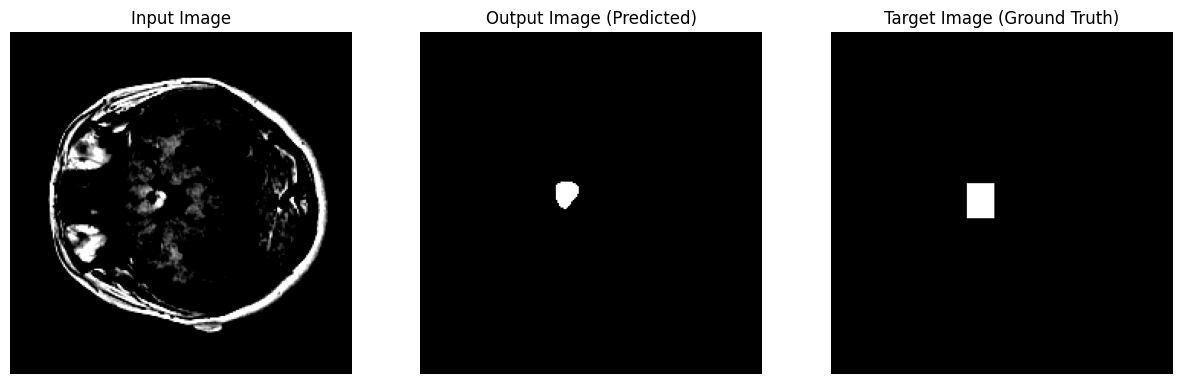

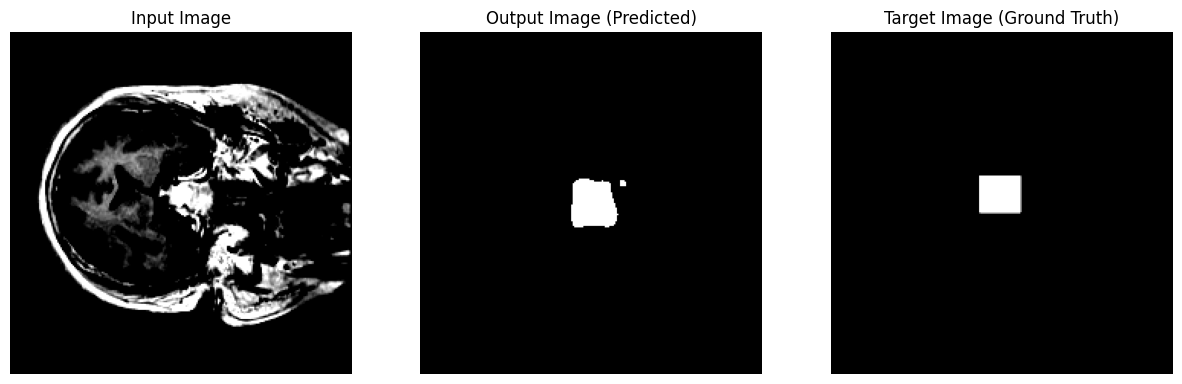

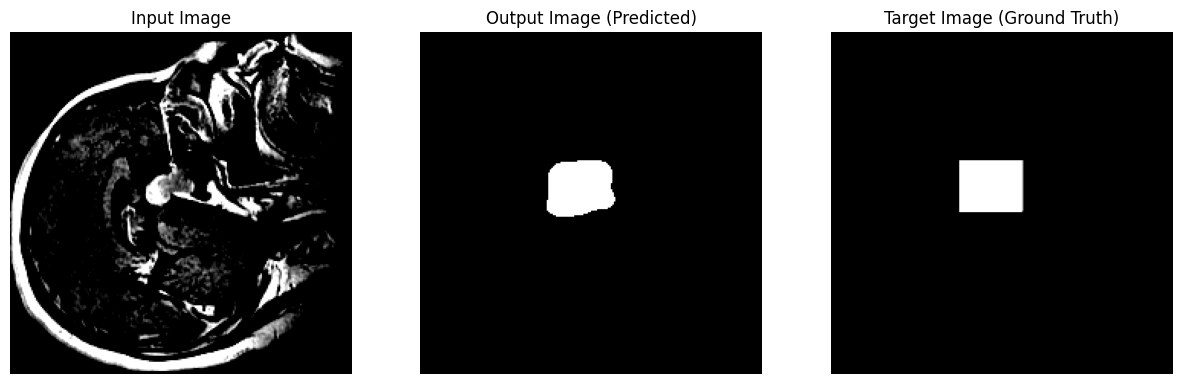

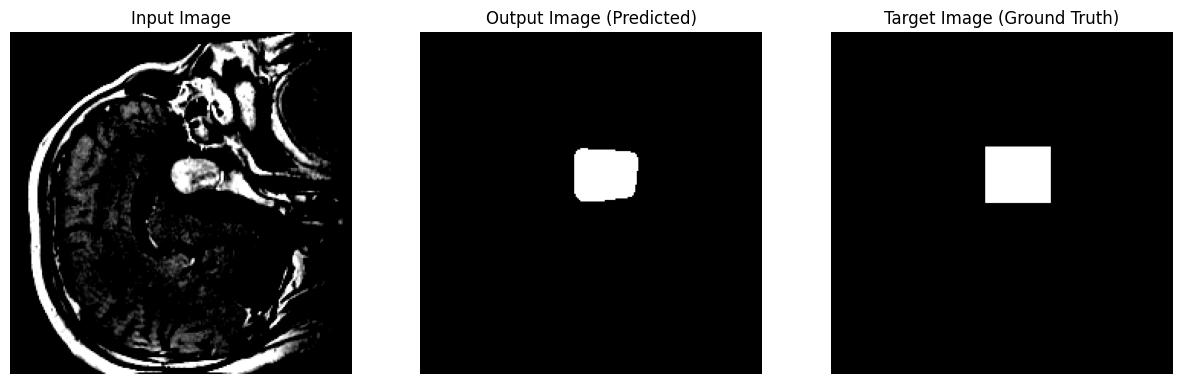

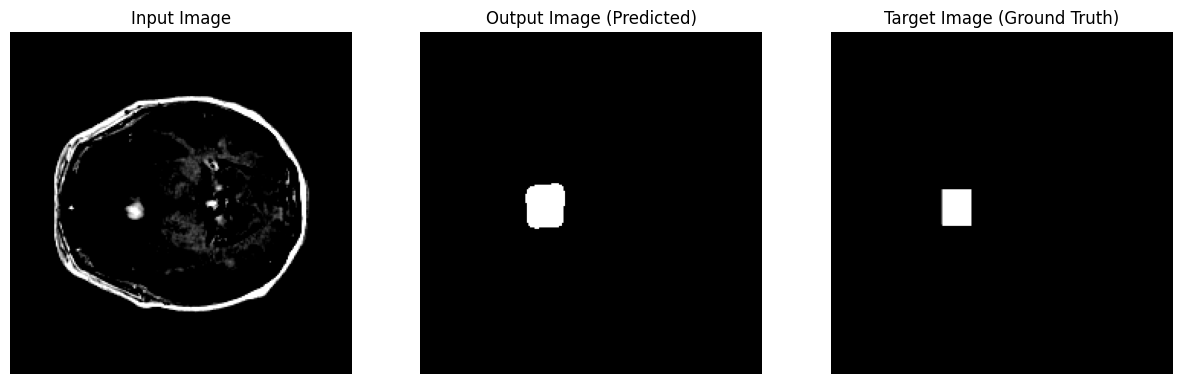

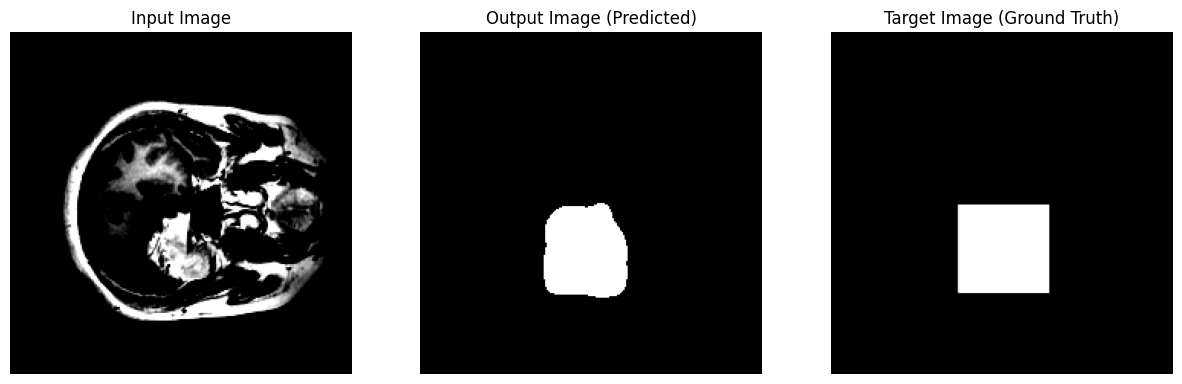

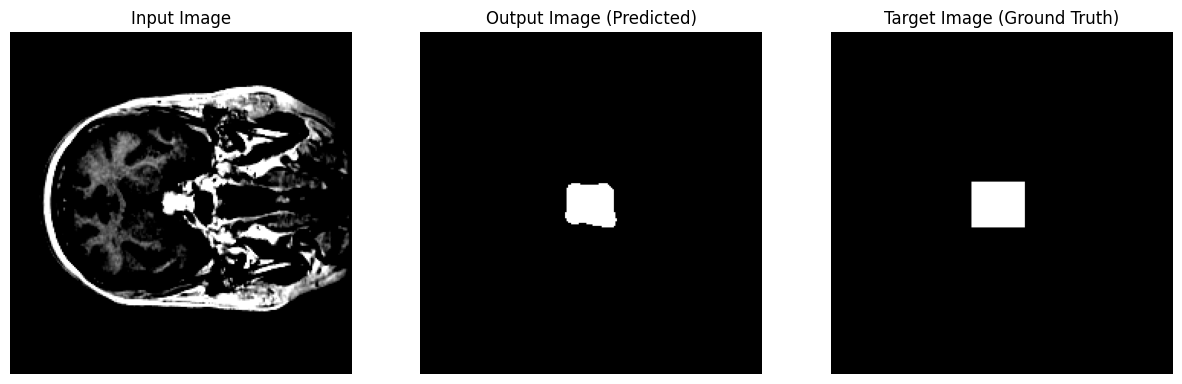

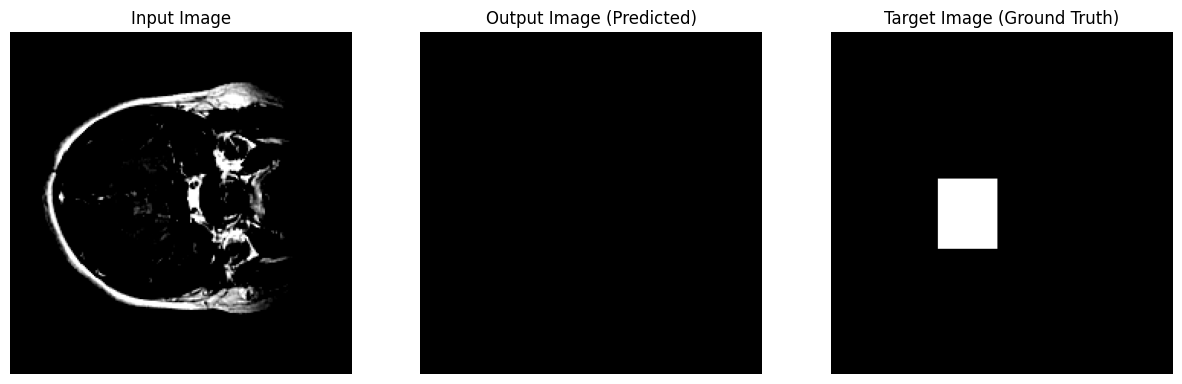

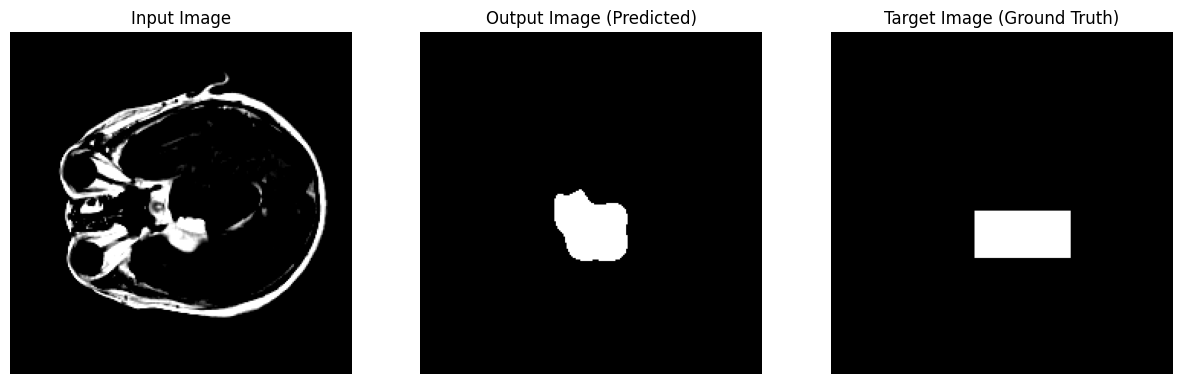

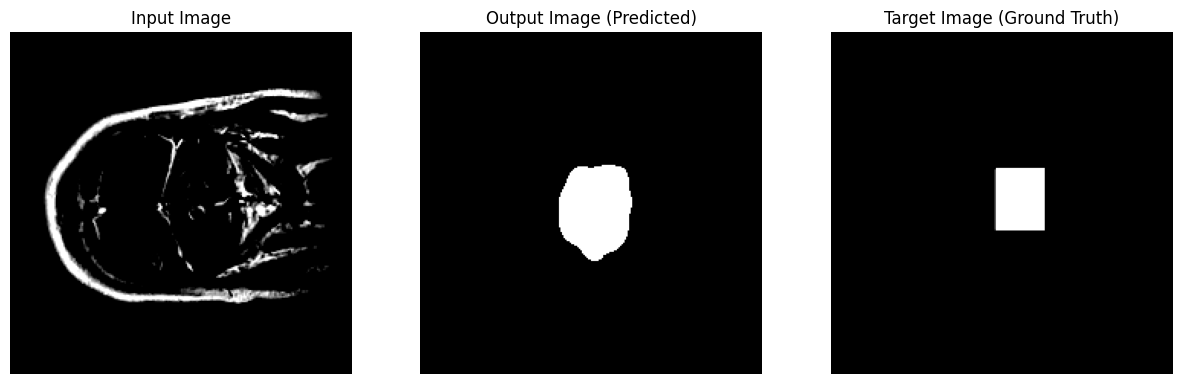

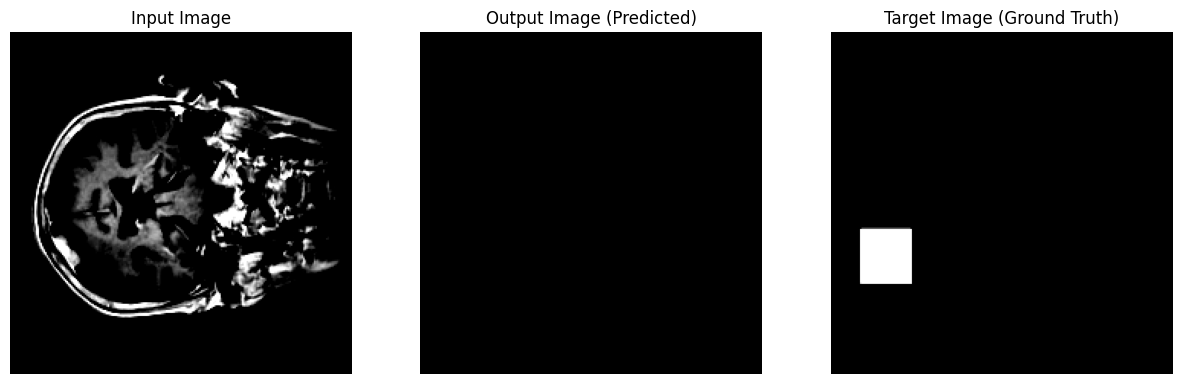

In [24]:
def visualize_input_output_target(input_image, output_image, target_image):
    # Move tensors to CPU memory if they are on CUDA devices
    input_image = input_image.cpu()
    output_image = output_image.cpu()
    target_image = target_image.cpu()

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Plot input image
    axes[0].imshow(input_image.squeeze().numpy(), cmap='gray')
    axes[0].set_title('Input Image')
    axes[0].axis('off')

    # Plot output image (predicted binary mask)
    axes[1].imshow(output_image.squeeze().numpy(), cmap='gray')
    axes[1].set_title('Output Image (Predicted)')
    axes[1].axis('off')

    # Plot target image (ground truth binary mask)
    axes[2].imshow(target_image.squeeze().numpy(), cmap='gray')
    axes[2].set_title('Target Image (Ground Truth)')
    axes[2].axis('off')

    plt.show()
    fig.savefig("output.png")

# Assuming you have defined your model, valid_loader, and DEVICE earlier in the code

with torch.no_grad():  # Ensure no gradients are computed during inference
    for batch, (X, y) in enumerate(valid_loader):
        X = X.to(DEVICE, dtype=torch.float32)
        y = y.to(DEVICE, dtype=torch.float32)

        y_pred_logits = model1(X)

        # Assuming y_pred_logits is a tuple containing multiple outputs
        # You need to determine which element of the tuple corresponds to the predictions
        y_pred = y_pred_logits[0]  # Adjust this index as needed
        
        # Assuming y_pred contains probabilities or logits for each pixel
        # You may need to apply thresholding or other post-processing to get binary images
        # Here, we'll just consider values above 0.5 as foreground (1) and below as background (0)
        y_pred_binary = (y_pred > 0.5).float()

        # Visualize input, output, and target binary images for the first batch
        visualize_input_output_target(X[0], y_pred_binary[0], y[0])


### Model 2

In [25]:
from tqdm import tqdm
from IPython.display import clear_output

best_val_loss = float('inf')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_losses = []
val_losses = []
train_ious = []
val_ious = []
num_no_improve = 0

model2.to(device)  # Move the model to the appropriate device

for epoch in range(NUM_EPOCHS):
    train_loss, train_iou = train(model2, optimizer2, loss_fn, train_loader, device)  # Train the model
    val_loss, val_iou = valid(model2, valid_loader, loss_fn, device)  # Validate the model
    
    train_losses.append(train_loss)  # Save the training loss
    val_losses.append(val_loss)  # Save the validation loss
    train_ious.append(train_iou)  # Save the training IoU
    val_ious.append(val_iou)  # Save the validation IoU
    
    clear_output(wait=True)
    print(f'Epoch {epoch+1}/{NUM_EPOCHS}, Train Loss: {train_loss:.4f}, Train IoU: {train_iou:.4f}')
    print(f'Validation Loss: {val_loss:.4f}, Validation IoU: {val_iou:.4f}')
    
    if val_loss < best_val_loss:  # Save the model with the best validation loss
        best_val_loss = val_loss
        print("Saving the model")
        torch.save(model2.state_dict(), checkpoints_path)  # Save Best Model
    
    if val_loss > best_val_loss:
        best_dict = torch.load(checkpoints_path)
        print('Loading Best Model')
        model2.load_state_dict(best_dict)
    
    # Check for early stopping, If the validation loss does not improve for 5 consecutive epochs, stop the training
    if len(val_losses) > 1: 
        if val_loss <= best_val_loss: 
            num_no_improve += 1
        else:
            num_no_improve = 0
            
    if num_no_improve >= 10:
        print("Early stopping")
        break


Epoch 35/35, Train Loss: 0.1903, Train IoU: 0.6828
Validation Loss: 0.3852, Validation IoU: 0.4663
Loading Best Model


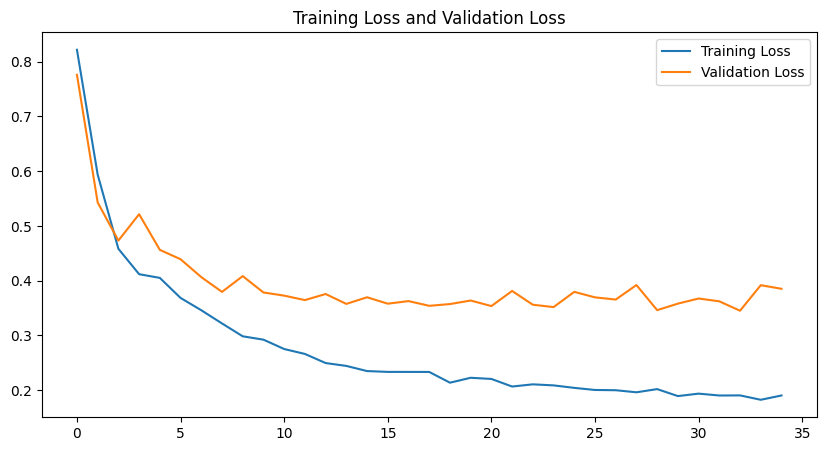

In [26]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training Loss and Validation Loss')
plt.legend()
plt.show(block=False)

The Dice loss of 0.1903 and Train IoU of 0.6828 on the train data indicated that more of the true image and predicted image on the train data is correctly classified, this shows us that the model is performing good on the train data. The model can be improved by increasing the number of epochs, increasing the learning rate, and increasing the batch size.

The Diceloss of the validation data is 0.3852, with it having half more than the diceloss of the train data this shows that the model is overfitting. The model can be improved by increasing the number of epochs, increasing the learning rate, and increasing the batch size.

The overfitting of the model can also be seen on the graph wtih the validation and training loss having such a large gap, with training lossbeing in the bottom

The form of the predicted mask is also rectangular, which could be more suited to image detection tasks. The prediction maybe improved by using a different model approach.

#### Model Inferencing

In [27]:
test_loss = valid(model2,test_loader,loss_fn,device)
print(f'Test data DiceLoss, IOU : {test_loss}')

Test data DiceLoss, IOU : (0.3692455547196524, 0.47428224767957416)


With the Test data diceloss of 0.4335, it meant that around 43% of the predicted point is not overlapping with the ground truth. Or in layman terms, the model has an average error rate of 43%

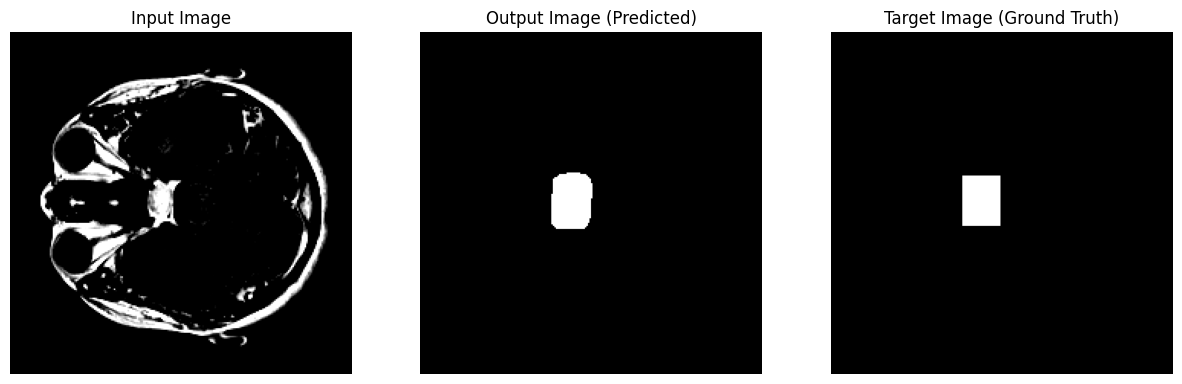

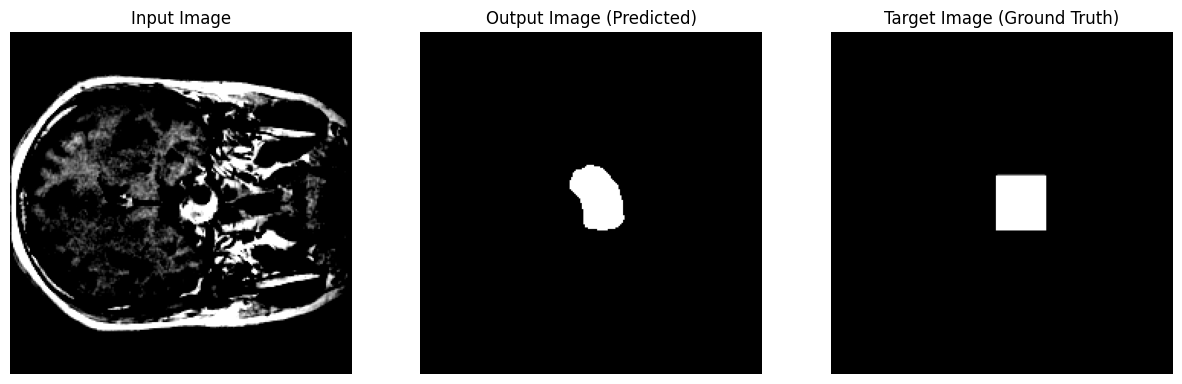

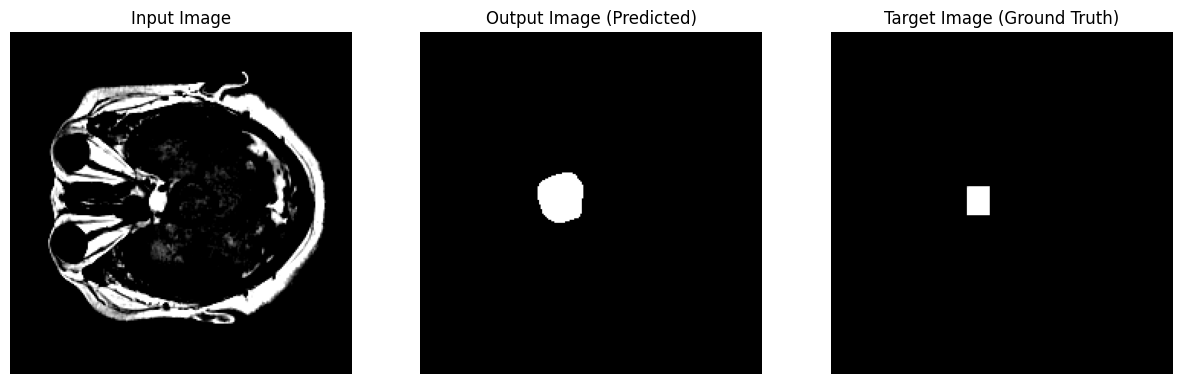

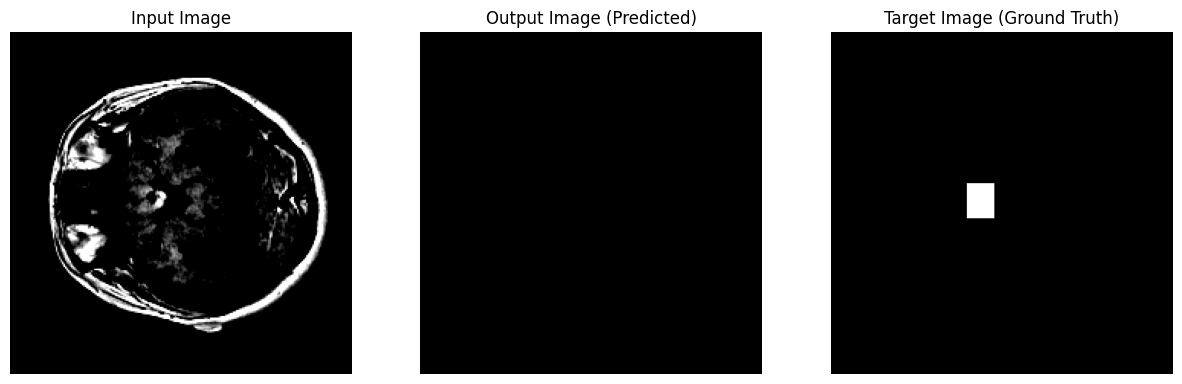

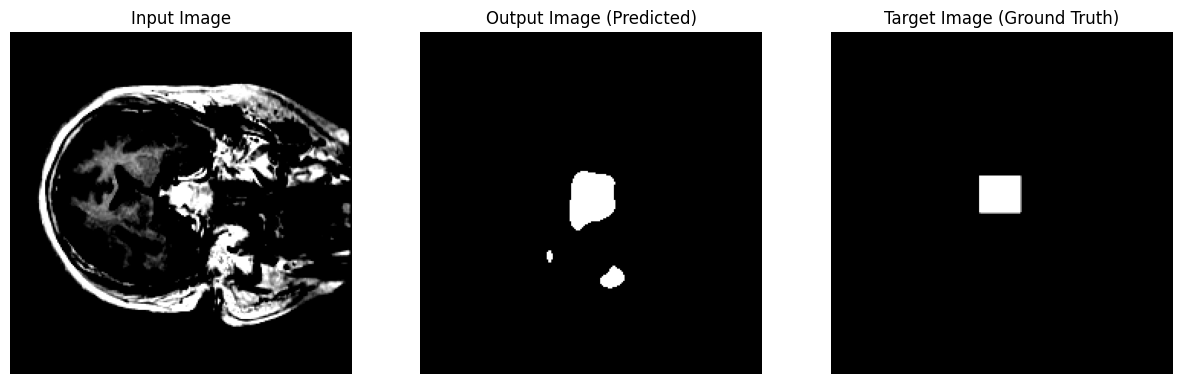

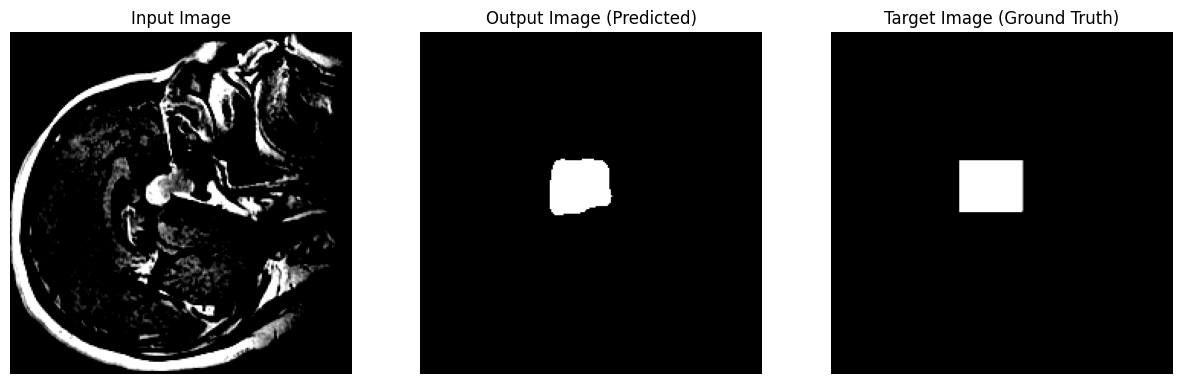

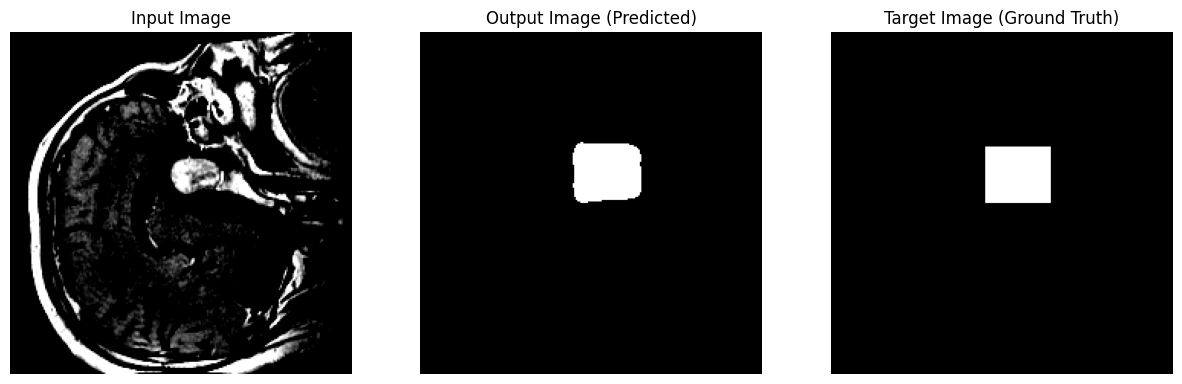

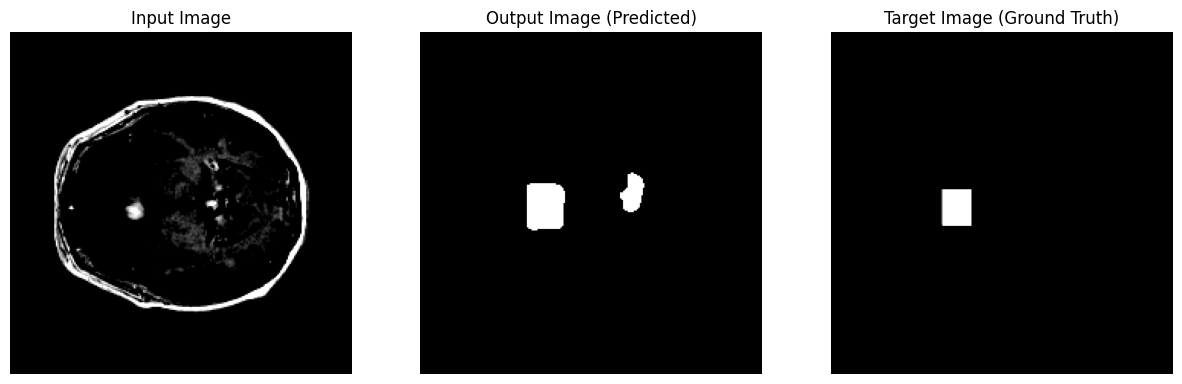

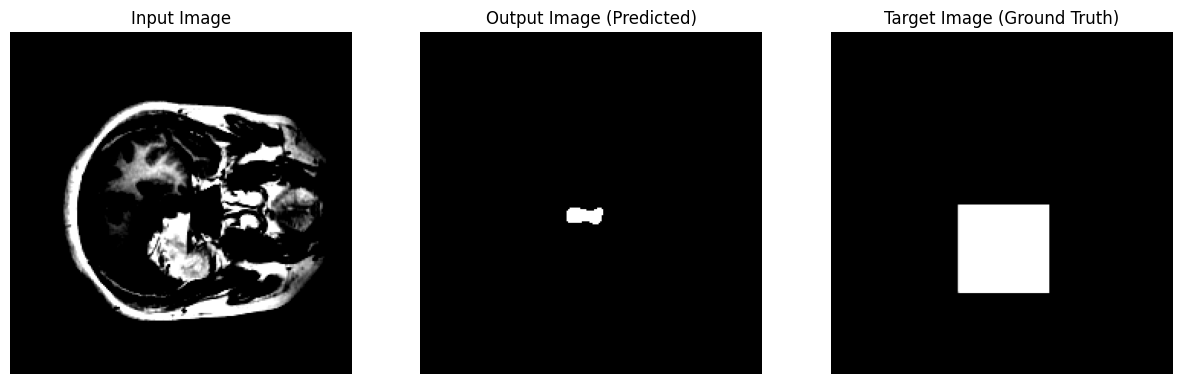

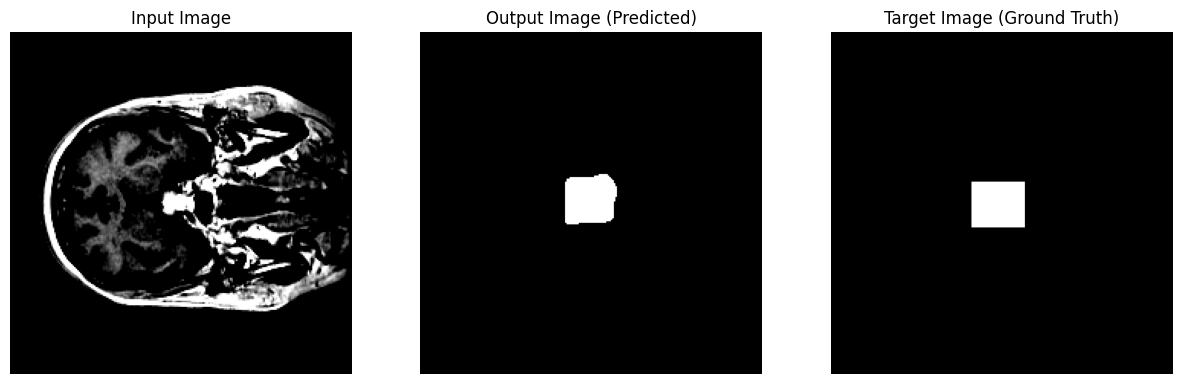

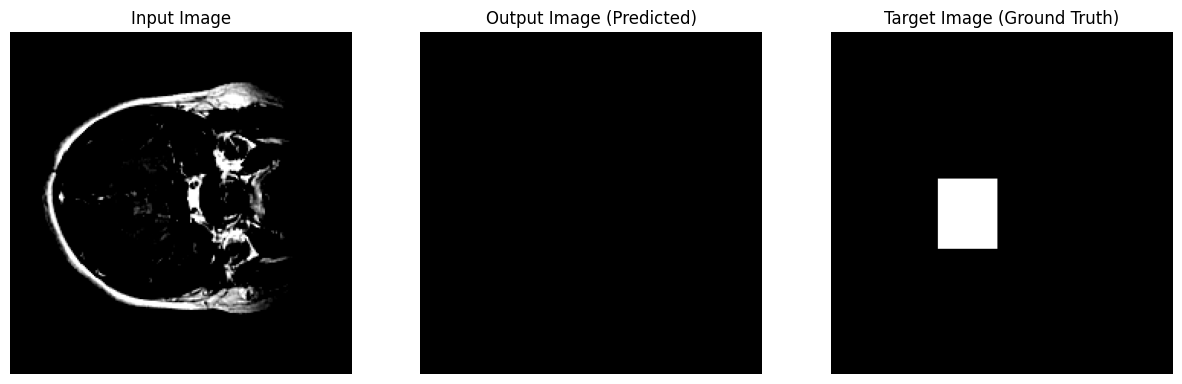

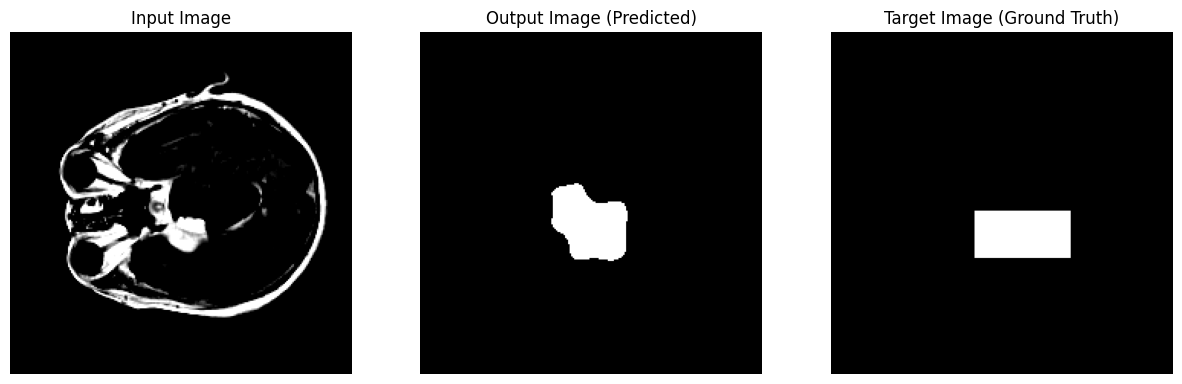

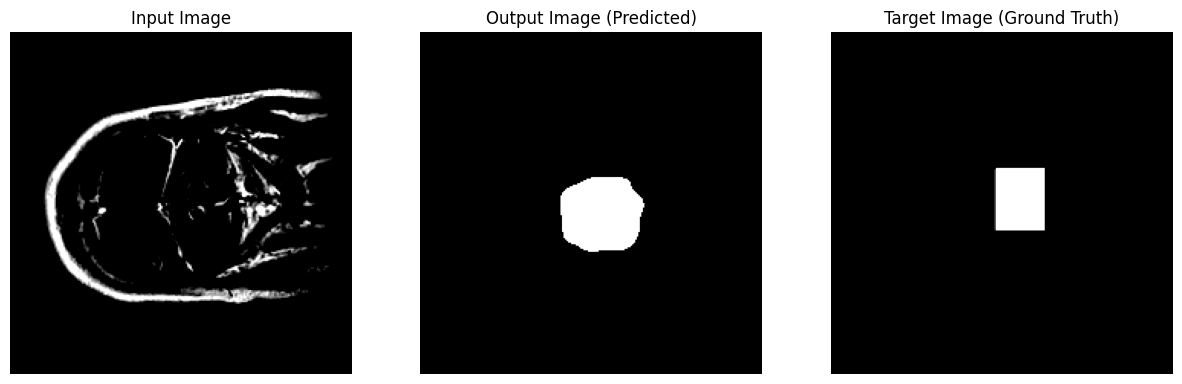

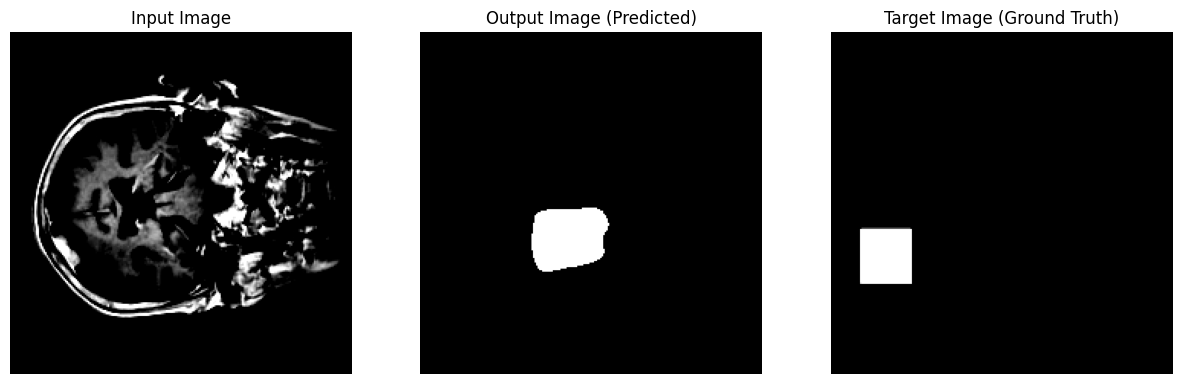

In [28]:
def visualize_input_output_target(input_image, output_image, target_image):
    # Move tensors to CPU memory if they are on CUDA devices
    input_image = input_image.cpu()
    output_image = output_image.cpu()
    target_image = target_image.cpu()

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Plot input image
    axes[0].imshow(input_image.squeeze().numpy(), cmap='gray')
    axes[0].set_title('Input Image')
    axes[0].axis('off')

    # Plot output image (predicted binary mask)
    axes[1].imshow(output_image.squeeze().numpy(), cmap='gray')
    axes[1].set_title('Output Image (Predicted)')
    axes[1].axis('off')

    # Plot target image (ground truth binary mask)
    axes[2].imshow(target_image.squeeze().numpy(), cmap='gray')
    axes[2].set_title('Target Image (Ground Truth)')
    axes[2].axis('off')

    plt.show()
    fig.savefig("output.png")

# Assuming you have defined your model, valid_loader, and DEVICE earlier in the code

with torch.no_grad():  # Ensure no gradients are computed during inference
    for batch, (X, y) in enumerate(valid_loader):
        X = X.to(DEVICE, dtype=torch.float32)
        y = y.to(DEVICE, dtype=torch.float32)

        y_pred_logits = model2(X)

        # Assuming y_pred_logits is a tuple containing multiple outputs
        # You need to determine which element of the tuple corresponds to the predictions
        y_pred = y_pred_logits[0]  # Adjust this index as needed
        
        # Assuming y_pred contains probabilities or logits for each pixel
        # You may need to apply thresholding or other post-processing to get binary images
        # Here, we'll just consider values above 0.5 as foreground (1) and below as background (0)
        y_pred_binary = (y_pred > 0.5).float()

        # Visualize input, output, and target binary images for the first batch
        visualize_input_output_target(X[0], y_pred_binary[0], y[0])


### Model 3

In [18]:
from tqdm import tqdm
from IPython.display import clear_output

best_val_loss = float('inf')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_losses = []
val_losses = []
train_ious = []
val_ious = []
num_no_improve = 0

model3.to(device)  # Move the model to the appropriate device

for epoch in range(NUM_EPOCHS):
    train_loss, train_iou = train(model3, optimizer3, loss_fn, train_loader, device)  # Train the model
    val_loss, val_iou = valid(model3, valid_loader, loss_fn, device)  # Validate the model
    
    train_losses.append(train_loss)  # Save the training loss
    val_losses.append(val_loss)  # Save the validation loss
    train_ious.append(train_iou)  # Save the training IoU
    val_ious.append(val_iou)  # Save the validation IoU
    
    clear_output(wait=True)
    print(f'Epoch {epoch+1}/{NUM_EPOCHS}, Train Loss: {train_loss:.4f}, Train IoU: {train_iou:.4f}')
    print(f'Validation Loss: {val_loss:.4f}, Validation IoU: {val_iou:.4f}')
    
    if val_loss < best_val_loss:  # Save the model with the best validation loss
        best_val_loss = val_loss
        print("Saving the model")
        torch.save(model3.state_dict(), checkpoints_path)  # Save Best Model
    
    if val_loss > best_val_loss:
        best_dict = torch.load(checkpoints_path)
        print('Loading Best Model')
        model3.load_state_dict(best_dict)
    
    # Check for early stopping, If the validation loss does not improve for 5 consecutive epochs, stop the training
    if len(val_losses) > 1: 
        if val_loss <= best_val_loss: 
            num_no_improve += 1
        else:
            num_no_improve = 0
            
    if num_no_improve >= 10:
        print("Early stopping")
        break


  0%|          | 0/47 [00:26<?, ?it/s]


RuntimeError: CUDA error: out of memory
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1.
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.
